<a href="https://colab.research.google.com/github/kamalesh465/google_colab/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow-gpu


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
!pip install tensorflow

In [88]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [89]:
## import some basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [91]:
## devide the dataset into dependent and independent features
X = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]

In [92]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [93]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [94]:
## ferature engineering
geography = pd.get_dummies(X['Geography'],drop_first=True)
gender = pd.get_dummies(X['Gender'],drop_first = True)

In [95]:
geography.head()

,Germany,Spain
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True


In [96]:
##  concatenate these variables with dataframe
X = X.drop(['Geography','Gender'],axis=1)


In [97]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [98]:
pd.concat([X,geography,gender],axis=1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [99]:
## splitting the dataset into Trainihg set and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size=0.2,random_state=0)

In [100]:
## feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [101]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.10643166],
       [-2.30455945,  0.30102557, -1.37744033, ...,  0.64259497,
         0.9687384 , -0.74866447],
       [-1.19119591, -0.94312892, -1.031415  , ...,  0.64259497,
        -1.03227043,  1.48533467],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.41231994],
       [-0.62420521, -0.08179119,  1.39076231, ...,  0.64259497,
         0.9687384 ,  0.84432121],
       [-0.28401079,  0.87525072, -1.37744033, ...,  0.64259497,
        -1.03227043,  0.32472465]])

In [102]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  0.64259497,
         0.9687384 ,  1.61085707],
       [-1.31490297,  0.10961719, -1.031415  , ...,  0.64259497,
        -1.03227043,  0.49587037],
       [ 0.57162971,  0.30102557,  1.04473698, ...,  0.64259497,
         0.9687384 , -0.42478674],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ...,  0.64259497,
        -1.03227043,  0.71888467],
       [-0.00566991, -0.46460796, -0.33936434, ...,  0.64259497,
         0.9687384 , -1.54507805],
       [-0.79945688, -0.84742473,  1.04473698, ...,  0.64259497,
        -1.03227043,  1.61255917]])

In [103]:
X_train.shape

(8000, 8)

In [104]:
X_test.shape

(2000, 8)

In [105]:
## part2 Now lets create the ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

In [106]:
### lets initialize the ANN
classifier = Sequential()



In [107]:
## adding the input layer
classifier.add(Dense(units=11,activation='relu'))

In [123]:
## adding the first hidden layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.2))

In [125]:
## adding the second hidden layer
classifier.add(Dense(units=6,activation='relu'))
classifier.add(Dropout(0.3))

In [126]:
## adding the outoput layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [127]:
classifier.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

In [128]:
import tensorflow as tf
opt = tf.keras.optimizers.Adam(learning_rate=0.01)

In [129]:
opt

In [130]:
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

In [131]:
model_history = classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks = early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8371 - loss: 0.4113 - val_accuracy: 0.8410 - val_loss: 0.3869
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8369 - loss: 0.3935 - val_accuracy: 0.8402 - val_loss: 0.3850
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8418 - loss: 0.3866 - val_accuracy: 0.8448 - val_loss: 0.3834
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8393 - loss: 0.3899 - val_accuracy: 0.8376 - val_loss: 0.3927
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8423 - loss: 0.3819 - val_accuracy: 0.8364 - val_loss: 0.3847
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8391 - loss: 0.3885 - val_accuracy: 0.8368 - val_loss: 0.3932
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8444 - loss: 0.3849 - val_accuracy: 0.8376 - val_loss: 0.3845
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8447 - loss: 0.3836 - 

In [132]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

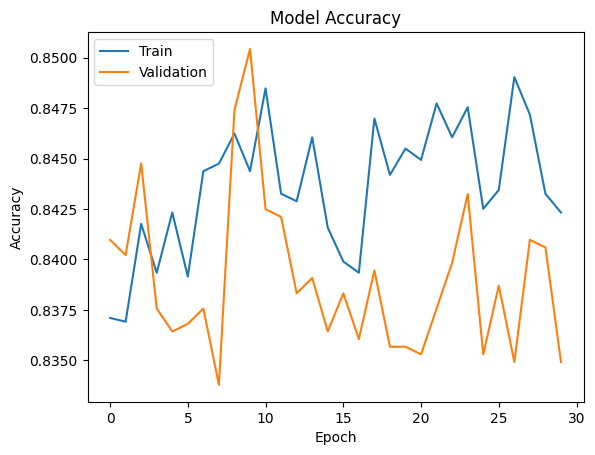

In [133]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

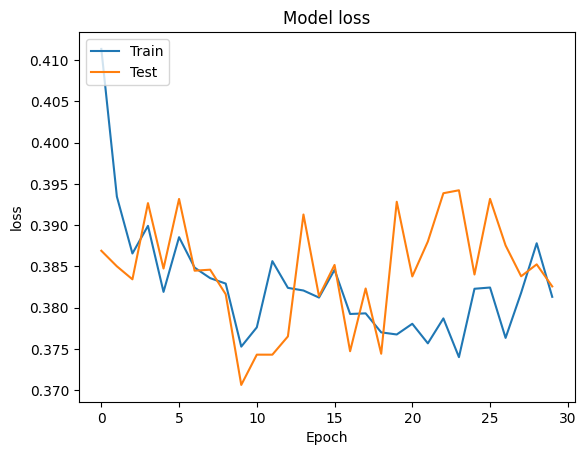

In [134]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])

plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

In [135]:
#part 3 - Making the predictions and evaluation  the model
# predicting the Test set result
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [136]:
## make the confustion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[1577,   18],
       [ 287,  118]])

In [137]:
## calculate the accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred,y_test)
score

0.8475

In [138]:
 # get the weights
 classifier.get_weights()

[array([[-0.04370096,  0.29378507, -0.4226247 ,  0.4196583 , -1.138015  ,
         -0.51194715, -2.918997  , -0.33002514,  1.0836196 ,  0.3341759 ,
          1.556163  ],
        [ 2.1836576 , -1.3065597 ,  3.8239505 , -2.4859064 , -1.4504704 ,
         -4.411171  , -1.7298743 ,  0.5458799 , -1.8649464 ,  0.24801874,
         -1.999054  ],
        [ 0.8745301 , -0.6849151 , -0.78759277,  1.341676  ,  2.3784473 ,
         -0.29589105,  1.9297545 ,  0.13978845, -1.4971262 ,  0.5385476 ,
         -0.6505332 ],
        [-0.52082527, -0.75876015,  0.31267428, -3.784701  ,  0.07928975,
         -0.6663375 ,  0.42843825, -4.6744623 , -1.9413736 ,  0.16782504,
          0.24506442],
        [-1.4929271 , -6.4051642 , -2.4438555 ,  0.24496384, -1.1146451 ,
         -0.75257725,  0.02760628, -1.8227918 , -2.0919077 ,  4.0014634 ,
         -1.6658924 ],
        [ 0.45758915, -0.01082719, -0.08958332, -1.3730037 ,  1.0459014 ,
         -1.2782613 ,  0.05062604, -0.2534553 , -0.08145113, -0.5318832